# 06 — Error Analysis

This notebook characterizes the mistakes made by the **pre-transaction
model** -- the one [04_advanced_modeling.ipynb](04_advanced_modeling.ipynb)
established as this project's primary, deployable result after finding that
the original full-feature model's near-perfect scores were driven by
leakage through post-transaction balance fields.

That leakage fix has a side benefit for this notebook specifically: the old
full-feature model was so accurate it left almost nothing to analyze (a
handful of misses in over half a million test transactions). The
pre-transaction model's more realistic performance gives us a genuine
population to work with -- **440 false negatives and 2,059 false
positives** -- so the patterns below are actual statistical trends, not
anecdotes about one or two rows.

We look at both error types, since they represent different costs to the
business:

- **False negatives** -- fraud that got through. Direct financial loss.
- **False positives** -- legitimate transactions incorrectly flagged.
  Customer friction, support burden, potential reputational cost.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

df = pd.read_csv("data/processed/engineered_transactions.csv")
metadata = joblib.load("models/model_metadata.joblib")
model = joblib.load("models/best_pretransaction_model.joblib")
pretxn_feature_cols = metadata["pre_txn_feature_cols"]
print("Analyzing errors for the primary (pre-transaction) model:", metadata["best_pretxn_model_name"])

cutoff_step = np.quantile(df["step"], 0.8)
test_mask = df["step"] > cutoff_step

X_test = df.loc[test_mask, pretxn_feature_cols]
y_test = df.loc[test_mask, "isFraud"]
scores_test = model.predict_proba(X_test)[:, 1]
preds_test = (scores_test >= 0.5).astype(int)

results = df.loc[test_mask].copy()
results["predicted_score"] = scores_test
results["predicted_label"] = preds_test

true_positives = results[(results["isFraud"] == 1) & (results["predicted_label"] == 1)]
false_negatives = results[(results["isFraud"] == 1) & (results["predicted_label"] == 0)]
false_positives = results[(results["isFraud"] == 0) & (results["predicted_label"] == 1)]
true_negatives = results[(results["isFraud"] == 0) & (results["predicted_label"] == 0)]

print(f"True positives:  {len(true_positives):,}")
print(f"False negatives: {len(false_negatives):,}")
print(f"False positives: {len(false_positives):,}")
print(f"True negatives:  {len(true_negatives):,}")


Analyzing errors for the primary (pre-transaction) model: XGBoost + undersample


True positives:  3,818
False negatives: 440
False positives: 2,059
True negatives:  546,187


## 1. False negatives -- the fraud that was missed

### The single clearest pattern: transaction type

Fraud in this dataset only occurs in `TRANSFER` and `CASH_OUT` transactions,
and the pre-transaction model does **not** treat them equally.


In [2]:
fraud_test = results[results["isFraud"] == 1]
recall_by_type = fraud_test.groupby("type_TRANSFER")["predicted_label"].mean()
recall_by_type.index = ["CASH_OUT", "TRANSFER"]
recall_by_type.name = "recall"
print(fraud_test.groupby("type_TRANSFER").size().rename("fraud_count"))
recall_by_type


type_TRANSFER
0    2129
1    2129
Name: fraud_count, dtype: int64


CASH_OUT    0.795209
TRANSFER    0.998121
Name: recall, dtype: float64

That's a large, meaningful gap: **99.8% recall on `TRANSFER` fraud vs. 79.5%
on `CASH_OUT` fraud.** Consistent with that, false negatives are almost
entirely `CASH_OUT` transactions (barely 1% are `TRANSFER`). Whatever
pre-transaction signal the model relies on for `TRANSFER` fraud, it isn't
carrying over nearly as well to `CASH_OUT`.

### What else distinguishes a missed fraud case from a caught one

Comparing false negatives to true positives on the remaining features
(using medians, since amounts here are heavily right-skewed and a mean would
be misleading):


In [3]:
compare_cols = [
    "amount", "oldbalanceOrg", "oldbalanceDest", "type_TRANSFER",
    "hour_of_day", "orig_txn_count_prior", "dest_txn_count_prior",
    "orig_dual_role_prior", "dest_dual_role_prior",
]

fn_vs_tp = pd.concat([
    true_positives[compare_cols].assign(group="True Positive (caught)"),
    false_negatives[compare_cols].assign(group="False Negative (missed)"),
])

fn_vs_tp.groupby("group")[compare_cols].median().round(2).T


group,False Negative (missed),True Positive (caught)
amount,96047.04,601767.55
oldbalanceOrg,96047.04,601767.55
oldbalanceDest,330840.35,0.00
type_TRANSFER,0.00,1.00
hour_of_day,16.00,10.00
orig_txn_count_prior,0.00,0.00
dest_txn_count_prior,2.00,0.00
orig_dual_role_prior,0.00,0.00
dest_dual_role_prior,0.00,0.00


Two clean patterns:

- **Missed fraud is much smaller in dollar terms.** Median amount for a
  missed case is ~$96K vs. ~$602K for a caught one -- about a sixth the
  size. Larger transactions appear to trip the model's sense of "suspicious"
  more reliably than smaller ones.
- **Missed fraud goes to destination accounts that already look
  "established."** Caught fraud (true positives) overwhelmingly moves money
  into destination accounts with a **median prior balance of $0** and
  **zero prior transactions** -- brand-new, empty accounts, the classic
  "money mule" signature. Missed fraud, by contrast, has a median
  destination balance of **~$331K** and **2 prior transactions** at that
  destination. In other words: the model's strongest tell for fraud is
  "this money is going to a suspiciously fresh, empty account," and fraud
  that instead moves money into an account that already looks normal and
  active evades that signal entirely.


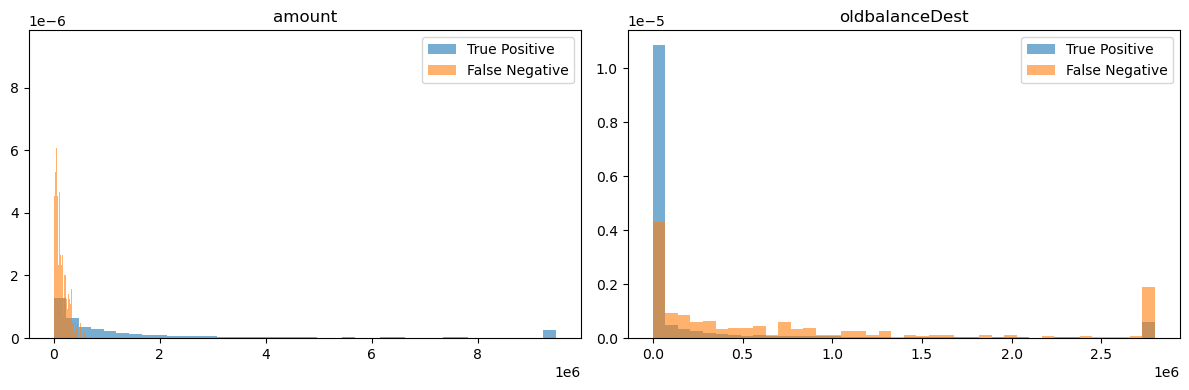

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ["amount", "oldbalanceDest"]):
    combined_cap = pd.concat([true_positives[col], false_negatives[col]]).quantile(0.95)
    ax.hist(true_positives[col].clip(upper=combined_cap), bins=40,
            alpha=0.6, label="True Positive", density=True)
    ax.hist(false_negatives[col].clip(upper=combined_cap), bins=40,
            alpha=0.6, label="False Negative", density=True)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()


## 2. False positives -- legitimate transactions we flagged

Same comparison, this time against a sample of correctly-cleared
transactions (true negatives), to see what makes a *legitimate* transaction
look suspicious to this model.


In [5]:
tn_sample = true_negatives.sample(min(20000, len(true_negatives)), random_state=42)

fp_vs_tn = pd.concat([
    tn_sample[compare_cols].assign(group="True Negative (correctly cleared)"),
    false_positives[compare_cols].assign(group="False Positive (wrongly flagged)"),
])

fp_vs_tn.groupby("group")[compare_cols].median().round(2).T


group,False Positive (wrongly flagged),True Negative (correctly cleared)
amount,163555.23,167706.16
oldbalanceOrg,160528.27,543.50
oldbalanceDest,0.00,543630.28
type_TRANSFER,0.00,0.00
hour_of_day,13.00,17.00
orig_txn_count_prior,0.00,0.00
dest_txn_count_prior,0.00,3.00
orig_dual_role_prior,0.00,0.00
dest_dual_role_prior,0.00,0.00


This is close to a mirror image of the false-negative story, and it's a
cleaner explanation than "the model is just wrong":

- **Amount alone barely distinguishes them** -- false positives and typical
  cleared transactions have similar median amounts (~$164K vs. ~$167K).
- **But the account behavior around them looks a lot like fraud.** False
  positives typically drain a sizeable existing balance (median
  `oldbalanceOrg` ~$161K, vs. just ~$500 for a typical cleared transaction --
  most ordinary cleared transactions come from accounts with very little
  money in them to begin with) and send it to a destination account with
  **no prior balance and no prior transaction history** (median $0 and 0
  prior transactions -- statistically indistinguishable from the "fresh mule
  account" signature that drives most of our true positives). Typical
  cleared transactions, by contrast, go to destinations with a median prior
  balance of ~$547K and 3 prior transactions -- clearly established accounts.

So the false positives here are legitimate customers doing something
individually unremarkable -- moving a large share of their balance to an
account that happens to be new or rarely used (a new landlord, a
newly-added payee, a first-time large purchase) -- that coincidentally
matches the exact combination of signals the model has learned to associate
with fraud.


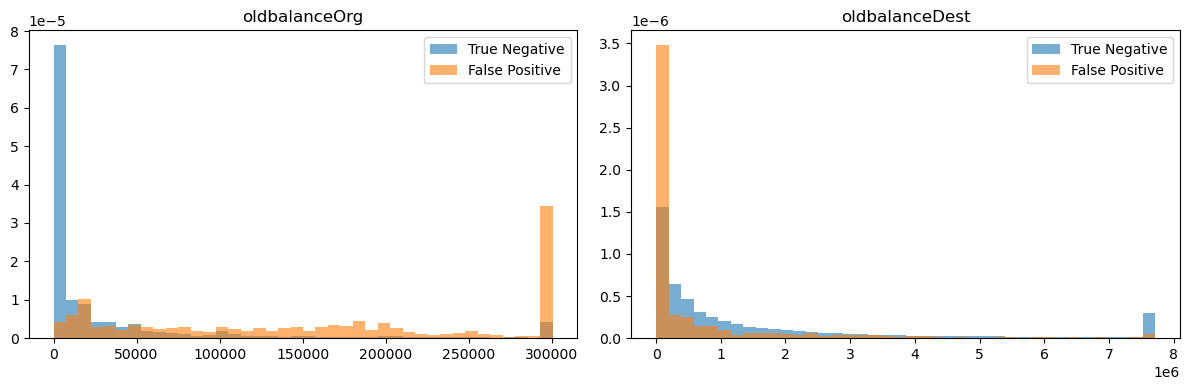

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ["oldbalanceOrg", "oldbalanceDest"]):
    combined_cap = pd.concat([tn_sample[col], false_positives[col]]).quantile(0.95)
    ax.hist(tn_sample[col].clip(upper=combined_cap), bins=40,
            alpha=0.6, label="True Negative", density=True)
    ax.hist(false_positives[col].clip(upper=combined_cap), bins=40,
            alpha=0.6, label="False Positive", density=True)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()


## 3. Tying findings back to feature engineering

This is the useful output of an error analysis: not just "the model gets
these wrong," but "here's what we'd add to fix it" -- and with 440 false
negatives and over 2,000 false positives to draw on, these are genuine
trends, not single-row anecdotes.

| Observation | Feature engineering response |
|---|---|
| `CASH_OUT` fraud recall (79.5%) lags `TRANSFER` fraud recall (99.8%) badly | Consider type-specific modeling -- either separate thresholds/calibration per transaction type, or explicit interaction features between `type_TRANSFER` and the balance/behavior features, so the model isn't forced to use one global decision boundary across two fraud patterns that behave differently. |
| The model's strongest signal -- "destination account is empty and brand-new" -- drives both true positives *and* false positives | This binary-ish signal (`oldbalanceDest` ≈ 0, `dest_txn_count_prior` = 0) can't distinguish a fresh mule account from a legitimate new payee. A graduated "destination account age/novelty" feature (e.g. steps since this destination account first appeared in the data at all, not just prior transaction count) could help separate "brand new to everyone" from "just new to this particular sender." |
| Missed fraud specifically targets destinations that already look established | Balance/recency features alone can't catch this. A genuine next step is network features -- e.g. whether this destination account has *ever* received funds flagged as fraud before, or is closely connected (1-2 hops) to an account that has -- which requires modeling the transaction graph, not just per-account aggregates. |
| Missed fraud tends to be smaller in dollar terms | A fixed-threshold view of `amount` doesn't account for what's unusual *for that specific account or destination*. Normalizing amount against the sending account's own typical transaction size, rather than using raw amount, could catch smaller fraud that currently blends into the noise of ordinary transactions. |

## Summary

- With the leakage fixed, the pre-transaction model makes a realistic and
  sizeable volume of both false negatives and false positives, giving this
  error analysis an actual population to draw conclusions from, not a
  handful of anecdotes.
- The single clearest pattern: **`CASH_OUT` fraud is caught far less
  reliably than `TRANSFER` fraud** (79.5% vs. 99.8% recall) using only
  pre-transaction features.
- Both error types trace back to the same root cause: the model leans
  heavily on "is the destination account empty and brand-new" as its
  strongest fraud signal. That correctly catches most `TRANSFER` fraud and
  fraud sent to fresh mule accounts, but it **misses fraud sent to
  already-active destinations** and **incorrectly flags legitimate
  customers** who happen to send a large share of their balance to a new or
  rarely-used account.
- The concrete next step for this project would be type-aware modeling,
  a more graduated "account novelty" feature, and network/mule-account
  signals -- rather than reaching back for the post-transaction fields we
  deliberately excluded in 04.

This closes the loop on the project: [02_feature_engineering.ipynb](02_feature_engineering.ipynb)
built the original features, [03](03_baseline_modeling.ipynb) and
[04](04_advanced_modeling.ipynb) modeled them (and caught a leakage problem
along the way), [05](05_interpretability.ipynb) explained the corrected
model's reasoning, and this notebook uses that reasoning to point at what to
build next.
